# Michaelis-Menten
***
## Setup the Environment
***

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
!{sys.executable} -m pip install matplotlib
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [3]:
import gillespy3d_pp as gillespy2

In [4]:
gillespy2.__file__

'/Users/anisgolriz/Desktop/GillesPy3D/simulation_lib/gillespy3d_pp/__init__.py'

In [5]:
def create_michaelis_menten(parameter_values=None):
    # Initialize Model
    model = gillespy2.Model(name="Michaelis_Menten")

    # Define Variables (GillesPy2.Species)
    A = gillespy2.Species(name='Substrate', initial_value=301)
    B = gillespy2.Species(name='Enzyme', initial_value=120)
    C = gillespy2.Species(name='Enzyme_Substrate_Complex', 
                          initial_value=0)
    D = gillespy2.Species(name='Product', initial_value=0)
    
    # Add Variables to Model
    model.add_species([A, B, C, D])
    

    # Define Parameters
    rate1 = gillespy2.Parameter(name='rate1', expression=0.0017)
    rate2 = gillespy2.Parameter(name='rate2', expression=0.5)
    rate3 = gillespy2.Parameter(name='rate3', expression=0.1)
    
    # Add Parameters to Model
    model.add_parameter([rate1, rate2, rate3])
    
    # Define Reactions
    r1 = gillespy2.Reaction(
        name="r1", reactants={'Substrate': 1, 'Enzyme': 1}, 
        products={'Enzyme_Substrate_Complex': 1}, rate='rate1'
    )
    r2 = gillespy2.Reaction(
        name="r2", reactants={'Enzyme_Substrate_Complex': 1}, 
        products={'Substrate': 1, 'Enzyme': 1}, rate='rate2'
    )
    r3 = gillespy2.Reaction(
        name="r3", reactants={'Enzyme_Substrate_Complex': 1}, 
        products={'Enzyme': 1, 'Product': 1}, rate='rate3'
    )
    # Add Reactions to Model
    model.add_reaction([r1, r2, r3])
    
    # Define Timespan
    tspan = gillespy2.TimeSpan.linspace(end_t=100, num_points=101)
    
    # Set Model Timespan
    model.timespan(tspan)
    return model

### Instantiate the Model

In [6]:
model = create_michaelis_menten()

In [7]:
dir(gillespy2)

['Model',
 'NumPySSASolver',
 'Parameter',
 'Reaction',
 'Result',
 'Simulation',
 'Species',
 'TimeSpan',
 '__author__',
 '__builtins__',
 '__cached__',
 '__copyright__',
 '__description__',
 '__doc__',
 '__email__',
 '__file__',
 '__license__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__url__',
 '__version__',
 'core',
 'error',
 'log',
 'logging',
 'model',
 'parameter',
 'reaction',
 'result',
 'simulation',
 'solvers',
 'species',
 'sys',
 'timespan',
 'utils',
 'version']

recording  1.0
state  {'Substrate': np.float64(300.0), 'Enzyme': np.float64(119.0), 'Enzyme_Substrate_Complex': np.float64(1.0), 'Product': np.float64(0.0)}
recording  2.0
state  {'Substrate': np.float64(299.0), 'Enzyme': np.float64(118.0), 'Enzyme_Substrate_Complex': np.float64(2.0), 'Product': np.float64(0.0)}
recording  3.0
state  {'Substrate': np.float64(298.0), 'Enzyme': np.float64(117.0), 'Enzyme_Substrate_Complex': np.float64(3.0), 'Product': np.float64(0.0)}
recording  4.0
state  {'Substrate': np.float64(297.0), 'Enzyme': np.float64(116.0), 'Enzyme_Substrate_Complex': np.float64(4.0), 'Product': np.float64(0.0)}
recording  5.0
state  {'Substrate': np.float64(296.0), 'Enzyme': np.float64(115.0), 'Enzyme_Substrate_Complex': np.float64(5.0), 'Product': np.float64(0.0)}
recording  6.0
state  {'Substrate': np.float64(295.0), 'Enzyme': np.float64(114.0), 'Enzyme_Substrate_Complex': np.float64(6.0), 'Product': np.float64(0.0)}
recording  7.0
state  {'Substrate': np.float64(294.0), 'En

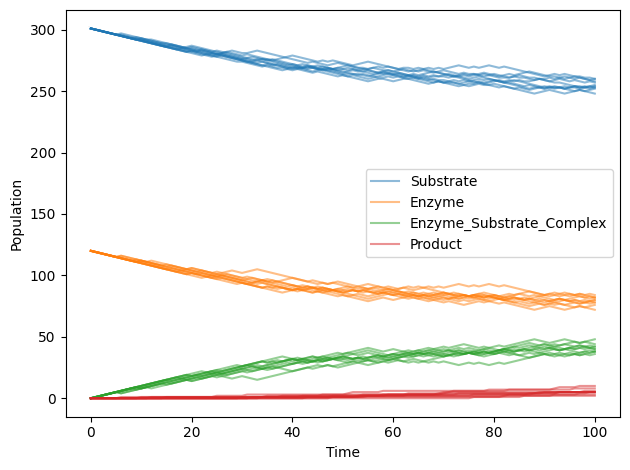

In [27]:
# The GillesPy3 way to run GillesPy3D
result = model.run(end_t=100,number_of_trajectories=10,dt=1)
result.plot()

traj 0  t: 0  Substrate: 301  Product:  0
traj 0  t: 0.007308005095841951  Substrate: 300.0  Product:  0.0
traj 0  t: 0.014225055503493289  Substrate: 299.0  Product:  0.0
traj 0  t: 0.02005441449695675  Substrate: 298.0  Product:  0.0
traj 0  t: 0.03368837402445735  Substrate: 297.0  Product:  0.0
traj 0  t: 0.03502238975619077  Substrate: 296.0  Product:  0.0
traj 0  t: 0.03631001235473458  Substrate: 295.0  Product:  0.0
traj 0  t: 0.05142777398640486  Substrate: 294.0  Product:  0.0
traj 0  t: 0.05383638574413845  Substrate: 293.0  Product:  0.0
traj 0  t: 0.054307316296114204  Substrate: 292.0  Product:  0.0
traj 0  t: 0.07445840606959764  Substrate: 291.0  Product:  0.0
traj 0  t: 0.07780305401541156  Substrate: 290.0  Product:  0.0
traj 0  t: 0.08269439220322693  Substrate: 289.0  Product:  0.0
traj 0  t: 0.0974049838628434  Substrate: 288.0  Product:  0.0
traj 0  t: 0.10267021766256637  Substrate: 287.0  Product:  0.0
traj 0  t: 0.1070110423790788  Substrate: 287.0  Product:  1

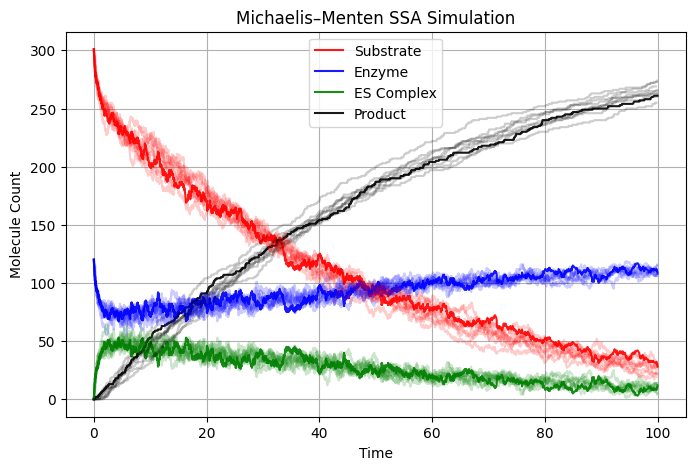

In [25]:
import matplotlib.pyplot as plt
#Temp graph for accuracy checks
#sim = gillespy2.Simulation(model, "SSA")
#sim = gillespy2.Simulation(model, NumPySSASolver())
num_traj = 10
traj_data =[]
for traj in range(num_traj):
    sim.reset() # reset the simulation after each run
    dt = 1;
    times = []
    substrate = []
    enzyme = []
    complex_ = []
    product = []
    prev_t = -1
    end_t = 100;
    while sim.get_time() < end_t:
        t = sim.get_time()
        if t == prev_t:
            raise RuntimeError("Time is not advancing")
        prev_t = t
        times.append(sim.get_time())
        substrate.append(sim.get_species('Substrate'))
        enzyme.append(sim.get_species('Enzyme'))
        complex_.append(sim.get_species('Enzyme_Substrate_Complex'))
        product.append(sim.get_species('Product'))
        #make f string
        print('traj',traj,' t:',sim.get_time(),' Substrate:',sim.get_species('Substrate'),' Product: ',sim.get_product('Product'))
        sim.run_until(sim.get_time()+dt);
    traj_data.append([times,substrate,enzyme,product,complex_])
    
plt.figure(figsize=(8, 5))

for i,(times,substrate,enzyme,product,complex_) in enumerate(traj_data):
    if i == 0:
        plt.plot(times, substrate, label='Substrate', color='red',alpha=.9)
        plt.plot(times, enzyme, label='Enzyme',color='blue',alpha=.9)
        plt.plot(times, complex_, label='ES Complex',color='green',alpha=.9)
        plt.plot(times, product, label='Product',color='black',alpha=.9)
    else:
        plt.plot(times, substrate, label='', color='red',alpha=.2)
        plt.plot(times, enzyme, label='',color='blue',alpha=.2)
        plt.plot(times, complex_, label='',color='green',alpha=.2)
        plt.plot(times, product, label='',color='black',alpha=.2)
    


plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title('Michaelis–Menten SSA Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# the other way to run GillesPy3Dimport matplotlib.pyplot as plt
sim = gillespy2.Simulation(model, "SSA",)
#sim = gillespy2.Simulation(model, NumPySSASolver())

number_of_trajectories = 10
for traj in range(num_traj):
    sim.reset() # reset the simulation after each run
    dt = .1;
    end_t = 10;
    while sim.get_time() < end_t:
        #make f string
        print('traj',traj,' t:',sim.get_time(),' Substrate:', sim.get_species('Substrate'))
        sim.run_until(sim.get_time()+dt);

TypeError: Simulation.__init__() missing 2 required positional arguments: 'dt' and 'end_t'

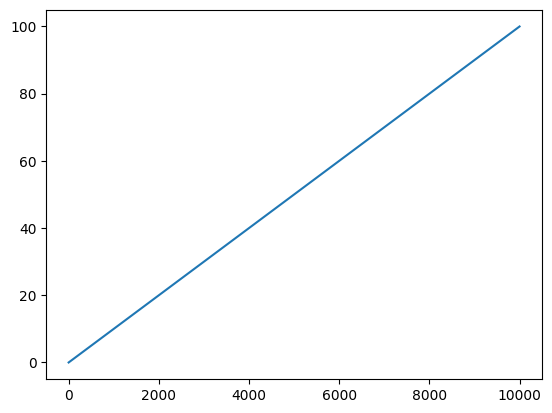

In [34]:
plt.plot(times)

In [25]:
substrate[-1]

np.float64(23.0)